<a href="https://colab.research.google.com/github/imk441/artificial-intelligence-class/blob/main/Customer_Churn_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction
University of Lahore | Artificial Intelligence Assignment 1

Ibrar Munir | SAP ID: 70176240

Run all cells from the folder containing `Telco_Customer_Churn.csv`. Install pandas, numpy, matplotlib and scikit-learn first. Outputs below were produced by executing these cells on the supplied CSV. The brief mentions Excel; the supplied CSV is loaded using read_csv. Churn Yes is the positive class (1).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
DATA_PATH = Path('Telco_Customer_Churn.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('output/Telco_Customer_Churn.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('First five customers:')
print(df.head().to_string(index=False))
print('\nColumn types:')
print(df.dtypes.to_string())
print('\nNumerical statistics:')
print(df.describe().round(2).to_string())
print('\nTarget counts:', df['Churn'].value_counts().to_dict())

Shape: (7043, 21)
First five customers:
customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService    MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies       Contract PaperlessBilling             PaymentMethod  MonthlyCharges TotalCharges Churn
7590-VHVEG Female              0     Yes         No       1           No No phone service             DSL             No          Yes               No          No          No              No Month-to-month              Yes          Electronic check           29.85        29.85    No
5575-GNVDE   Male              0      No         No      34          Yes               No             DSL            Yes           No              Yes          No          No              No       One year               No              Mailed check           56.95       1889.5    No
3668-QPYBK   Male              0      No         No       2          Yes               No             DSL   

## Cleaning decisions
Convert TotalCharges from text to numeric. Blank strings become missing values. Only fill a missing total with zero when tenure is zero, because no bill has accumulated yet. Other missing numerical values are imputed from the training data inside the model pipeline. Remove duplicate records if present. Preserve service categories such as No internet service: they describe real customer states.

In [3]:
print('Missing values before conversion:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate customer IDs:', int(df['customerID'].duplicated().sum()))
df = df.drop_duplicates().copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing TotalCharges after conversion:', int(df['TotalCharges'].isna().sum()))
zero_tenure = df['TotalCharges'].isna() & df['tenure'].eq(0)
print('Missing totals with zero tenure:', int(zero_tenure.sum()))
df.loc[zero_tenure, 'TotalCharges'] = 0
print('Remaining missing values:', int(df.isna().sum().sum()))
print('Target values:', sorted(df['Churn'].unique()))
assert df['Churn'].isin(['Yes', 'No']).all()
assert df['customerID'].is_unique
print('Cleaned shape:', df.shape)

Missing values before conversion: 0
Duplicate rows: 0
Duplicate customer IDs: 0
Missing TotalCharges after conversion: 11
Missing totals with zero tenure: 11
Remaining missing values: 0
Target values: ['No', 'Yes']
Cleaned shape: (7043, 21)


Churn percentages:
Churn
No     73.46
Yes    26.54

Churn rate by contract (%):
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83

Average tenure and monthly charges by churn:
       tenure  MonthlyCharges
Churn                        
No      37.57           61.27
Yes     17.98           74.44


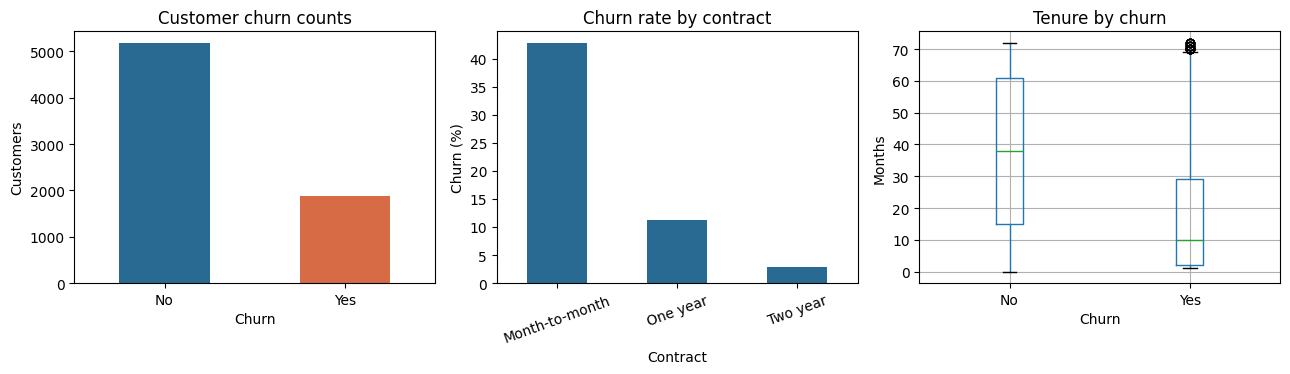

In [4]:
print('Churn percentages:')
print((df['Churn'].value_counts(normalize=True)*100).round(2).to_string())
print('\nChurn rate by contract (%):')
contract_rates = df.groupby('Contract')['Churn'].apply(lambda s: s.eq('Yes').mean()*100)
print(contract_rates.round(2).to_string())
print('\nAverage tenure and monthly charges by churn:')
print(df.groupby('Churn')[['tenure','MonthlyCharges']].mean().round(2).to_string())
fig, ax = plt.subplots(1,3,figsize=(13,4))
df['Churn'].value_counts().reindex(['No','Yes']).plot.bar(ax=ax[0],color=['#286a91','#d66b45'],rot=0)
ax[0].set(title='Customer churn counts',ylabel='Customers',xlabel='Churn')
contract_rates.plot.bar(ax=ax[1],color='#286a91',rot=20)
ax[1].set(title='Churn rate by contract',ylabel='Churn (%)',xlabel='Contract')
df.boxplot(column='tenure',by='Churn',ax=ax[2])
ax[2].set(title='Tenure by churn',ylabel='Months',xlabel='Churn')
fig.suptitle(''); fig.tight_layout()

## Features and evaluation design
X contains customer attributes except customerID and Churn. y is 1 for churn and 0 otherwise. SeniorCitizen is treated as a categorical flag. One-hot encoding avoids assigning artificial numerical order to service categories. Numerical scaling helps Logistic Regression. A stratified 80/20 split preserves class proportions. Three-fold stratified cross-validation on training data selects the model using churn F1; the test set is held out until selection. All learned preprocessing is fitted inside each training fold, preventing leakage.

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
X = df.drop(columns=['customerID','Churn']).copy()
X['SeniorCitizen'] = X['SeniorCitizen'].astype(str)
y = df['Churn'].map({'No':0,'Yes':1})
numeric = ['tenure','MonthlyCharges','TotalCharges']
categorical = [c for c in X.columns if c not in numeric]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print('Input feature count:', X.shape[1])
print('Numeric features:', numeric)
print('Categorical features:', categorical)
print('Training shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Training churn rate:', round(y_train.mean(),4))
print('Test churn rate:', round(y_test.mean(),4))

Input feature count: 19
Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Training shape: (5634, 19) Test shape: (1409, 19)
Training churn rate: 0.2654
Test churn rate: 0.2654


In [6]:
preprocessing = ColumnTransformer([
    ('numeric', Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler())]), numeric),
    ('categorical', Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encode',OneHotEncoder(handle_unknown='ignore'))]), categorical)
])
models = {
    'Logistic Regression': Pipeline([('prepare',preprocessing),('model',LogisticRegression(max_iter=2000,random_state=42))]),
    'Random Forest': Pipeline([('prepare',preprocessing),('model',RandomForestClassifier(n_estimators=150,min_samples_leaf=2,random_state=42,n_jobs=2))])
}
cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model,X_train,y_train,cv=cv,scoring='f1')
    cv_scores[name] = scores.mean()
    print(name, 'CV F1:', np.round(scores,4), 'Mean:', round(scores.mean(),4))
best_name = max(cv_scores,key=cv_scores.get)
print('Selected using training CV:', best_name)
for model in models.values():
    model.fit(X_train,y_train)
best_model = models[best_name]

Logistic Regression CV F1: [0.5761 0.5922 0.6174] Mean: 0.5952
Random Forest CV F1: [0.533  0.5727 0.547 ] Mean: 0.5509
Selected using training CV: Logistic Regression


                     Accuracy  Precision  Recall      F1
Model                                                   
Logistic Regression    0.8055     0.6572  0.5588  0.6040
Random Forest          0.7892     0.6323  0.4920  0.5534
Always No Churn baseline accuracy: 0.7346
Logistic Regression confusion matrix [TN FP; FN TP]: [[926, 109], [165, 209]]
Random Forest confusion matrix [TN FP; FN TP]: [[928, 107], [190, 184]]


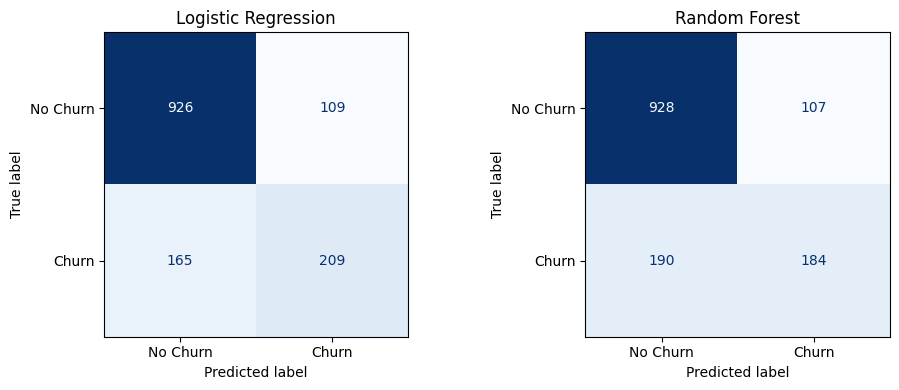

In [7]:
rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    rows.append({'Model':name,'Accuracy':accuracy_score(y_test,pred),'Precision':precision_score(y_test,pred,zero_division=0),'Recall':recall_score(y_test,pred,zero_division=0),'F1':f1_score(y_test,pred,zero_division=0)})
results = pd.DataFrame(rows).set_index('Model')
print(results.round(4).to_string())
print('Always No Churn baseline accuracy:', round((y_test==0).mean(),4))
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax,(name,model) in zip(axes,models.items()):
    cm = confusion_matrix(y_test,model.predict(X_test),labels=[0,1])
    print(name, 'confusion matrix [TN FP; FN TP]:', cm.tolist())
    ConfusionMatrixDisplay(cm,display_labels=['No Churn','Churn']).plot(ax=ax,colorbar=False,cmap='Blues')
    ax.set_title(name)
fig.tight_layout()

In [8]:
# These sample inputs are actual held-out customer rows, not invented outcomes.
sample_customers = X_test.iloc[:5].copy()
probabilities = best_model.predict_proba(sample_customers)[:,1]
predictions = best_model.predict(sample_customers)
print('Sample customer inputs:')
print(sample_customers.to_string())
sample_output = pd.DataFrame({
    'CustomerID':df.loc[sample_customers.index,'customerID'],
    'Churn probability':probabilities,
    'Prediction':np.where(predictions==1,'Churn','No Churn'),
    'Actual':np.where(y_test.loc[sample_customers.index]==1,'Churn','No Churn')
})
print('\nSelected model:', best_name)
print(sample_output.round(4).to_string(index=False))
# For a new customer, replace the input values below and keep all feature names.
new_customer = sample_customers.iloc[[0]].copy()
new_customer['tenure'] = 2
new_customer['Contract'] = 'Month-to-month'
new_customer['MonthlyCharges'] = 80.0
new_customer['TotalCharges'] = 160.0
print('\nIllustrative new customer probability:', round(best_model.predict_proba(new_customer)[0,1],4))
print('Illustrative prediction:', 'Churn' if best_model.predict(new_customer)[0]==1 else 'No Churn')

Sample customer inputs:
      gender SeniorCitizen Partner Dependents  tenure PhoneService MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling            PaymentMethod  MonthlyCharges  TotalCharges
437     Male             0     Yes        Yes      72          Yes           Yes     Fiber optic            Yes          Yes              Yes         Yes         Yes             Yes        Two year              Yes  Credit card (automatic)          114.05       8468.20
2280  Female             1      No         No       8          Yes           Yes     Fiber optic             No           No               No         Yes         Yes             Yes  Month-to-month              Yes  Credit card (automatic)          100.15        908.55
2235  Female             0     Yes        Yes      41          Yes           Yes             DSL            Yes          Yes              Yes          No         Yes 